# Potato

is one word.
It's a great word.
But only one word.

# Sentence Classification

How do we go beyond one word at a time?

The task: read a sentence, decide if it's positive or negative.

We'll try four things. Each one will be a small variation on the last, and each one will
break in a way that tells us what to do next.

![!img](../resources/imgs/6_2_task.png)

# Data & tokenization

Nothing conceptually new here, but we're **not** hiding it in a helper cell — the shapes
that come out of this section are the whole subject of the lesson, so we walk through it.

Two changes from 6.1.2:

1. **A real dataset**: SST-2 (Stanford Sentiment Treebank, binary). Short sentences, so our
   `T` stays small and everything trains in seconds.
2. **An off-the-shelf tokenizer** instead of `.split()`. See below for why.

In [1]:
from tqdm.auto import tqdm, trange
from datasets import load_dataset
from transformers import AutoTokenizer
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

torch.manual_seed(42)
# Check if you have nvidia GPU, you may be able to use cuda
device = 'mps' if torch.backends.mps.is_available() else 'cpu'
device

/Users/priyansh.trivedi/Dev/learning/dl-workinggroup/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


'mps'

In [2]:
sst2 = load_dataset("stanfordnlp/sst2")

# NOTE: SST-2's *test* split has hidden labels (all -1) because it's a GLUE leaderboard task.
#       So we use `validation` as our test set. This is standard practice for SST-2.
train = sst2["train"]
test  = sst2["validation"]

len(train), len(test), train[1]

(67349,
 872,
 {'idx': 1, 'sentence': 'contains no wit , only labored gags ', 'label': 0})

## Let's use a slightly modern (circa 2017) tokenizer

In 6.1.2 we split on whitespace and kept the top 10k words. Everything else became `<unk>`.

- **Unknown words.** Any word outside the top 10k is destroyed — it becomes the same vector as every other rare word.
- **Vocabulary size.** Remember the plot from 6.1: more documents, more unique words, forever.
- **Inefficient compression.** Deciding a tokenization scheme is very much like deciding a compression scheme. Splitting by space seems inefficient. Even for text.

We are using a **subword tokenizer**. Looks kinda like:

![](../resources/imgs/6_2_bert_subword_tok.png)

We are not going to implement it.

In [3]:
tok = AutoTokenizer.from_pretrained("bert-base-uncased")

# A common word is one piece. A rare word gets spelled out of pieces ("##" = "glued to the left")
print(tok.tokenize("the movie was not good"))
print(tok.tokenize("tokenization is unbelievably fiddly"))

print("vocab size:", tok.vocab_size, "| pad id:", tok.pad_token_id)

['the', 'movie', 'was', 'not', 'good']
['token', '##ization', 'is', 'un', '##bel', '##ie', '##va', '##bly', 'fi', '##dd', '##ly']
vocab size: 30522 | pad id: 0


In [4]:
# Lets take it for a spin
out = tok(["the movie was not good", "great"], padding=True, return_tensors="pt")

print(out["input_ids"])
print(out["attention_mask"])
print(tok.convert_ids_to_tokens(out["input_ids"][0]))

tensor([[ 101, 1996, 3185, 2001, 2025, 2204,  102],
        [ 101, 2307,  102,    0,    0,    0,    0]])
tensor([[1, 1, 1, 1, 1, 1, 1],
        [1, 1, 1, 0, 0, 0, 0]])
['[CLS]', 'the', 'movie', 'was', 'not', 'good', '[SEP]']


### The two tensors

- **`input_ids`** — `(B, T)`. The token ids. Note `[CLS]` at the front and `[SEP]` at the
  end (BERT's conventions; harmless for us) and `[PAD]` filling the short sentence out to
  the length of the long one, because a batch has to be a rectangle.
- **`attention_mask`** — `(B, T)`. Tells us what is a real token, what is a padding. `1` for a real token, `0` for padding.

PS: Don't worry about the "attention" part of the word. We'll visit it in next sesh ;)

In [5]:
MAXLEN = 64   # SST-2 sentences are short; this truncates almost nothing

def encode(texts):
    out = tok(texts, padding="max_length", truncation=True,
              max_length=MAXLEN, return_tensors="pt")
    return out["input_ids"], out["attention_mask"]

train_ids, train_mask = encode(train["sentence"])
test_ids,  test_mask  = encode(test["sentence"])
train_y = torch.tensor(train["label"], dtype=torch.float)
test_y  = torch.tensor(test["label"],  dtype=torch.float)

train_ids.shape, train_mask.shape, train_y.shape

(torch.Size([67349, 64]), torch.Size([67349, 64]), torch.Size([67349]))

In [6]:
# Onto the device up front (it all fits), then into dataloaders. Same as 6.1.2.
train_loader = DataLoader(
    TensorDataset(train_ids.to(device), train_mask.to(device), train_y.to(device)),
    batch_size=256, shuffle=True)
test_loader = DataLoader(
    TensorDataset(test_ids.to(device), test_mask.to(device), test_y.to(device)),
    batch_size=256)

for batch in train_loader:
    break
[t.shape for t in batch]

[torch.Size([256, 64]), torch.Size([256, 64]), torch.Size([256])]

# The training loop

Same five steps as always — `zero_grad`, forward, loss, `backward`, `step`. Provided, so we
don't spend the session on it.

A few conveniences, since we're going to run this five times today and want to *see* what
happened each time:

- **Two progress bars**: one across epochs, one across batches within an epoch. The inner one
  shows a running average loss that updates as it goes, so you can tell within a few seconds
  whether a model is learning or sulking.
- **Every batch's loss is logged**, not just the epoch average — with 264 batches an epoch,
  a per-epoch number is only three data points and you can't see anything in three points.
- **It trains the model in place** and returns the history. So the pattern is *build the model,
  look at it, then train it* — the model variable is yours before and after.
- **It plots at the end**: per-batch loss (with a moving average through the noise) next to
  per-epoch loss and test accuracy.

And a `report()` to print a model's entrails — every parameter, its shape, its size, and
whether it trains. That matters more than usual today, because half our story is about
*where the parameters live*.

In [7]:
lossfn = nn.BCEWithLogitsLoss()

def accuracy(logits, y):
    return ((logits > 0).float() == y).float().mean().item()

@torch.no_grad()
def evaluate(model):
    model.eval()
    accs = [accuracy(model(ids, mask), y) for ids, mask, y in test_loader]
    return sum(accs) / len(accs)


def report(model):
    """Print a model's entrails: what parameters exist, how big, and which ones learn."""
    total = trainable = 0
    print(f"{'parameter':<26}{'shape':<18}{'count':>12}   learns?")
    print("-" * 66)
    for name, prm in model.named_parameters():
        total += prm.numel()
        trainable += prm.numel() if prm.requires_grad else 0
        print(f"{name:<26}{str(tuple(prm.shape)):<18}{prm.numel():>12,}   "
              f"{'yes' if prm.requires_grad else 'FROZEN'}")
    print("-" * 66)
    print(f"{'':<26}{'TOTAL':<18}{total:>12,}   ({trainable:,} learn)")


def plot_history(history, name=""):
    """Left: loss at every batch. Right: per-epoch loss against test accuracy."""
    fig, ax = plt.subplots(1, 2, figsize=(11, 3.5), dpi=110)

    steps = history["batch_loss"]
    ax[0].plot(steps, alpha=0.25, lw=0.7, label="each batch")
    w = max(1, len(steps) // 100)                       # smooth through the noise
    if w > 1:
        smooth = np.convolve(steps, np.ones(w) / w, mode="valid")
        ax[0].plot(range(w - 1, len(steps)), smooth, lw=1.8, label=f"moving avg ({w})")
    ax[0].set_xlabel("batch"); ax[0].set_ylabel("loss")
    ax[0].set_title("loss, every single batch"); ax[0].legend()

    ep = range(1, len(history["epoch_loss"]) + 1)
    ax[1].plot(ep, history["epoch_loss"], "o-", color="tab:blue")
    ax[1].set_xlabel("epoch"); ax[1].set_ylabel("avg loss", color="tab:blue")
    ax[1].set_title("per epoch"); ax[1].set_xticks(list(ep))
    acc_ax = ax[1].twinx()
    acc_ax.plot(ep, history["test_acc"], "s--", color="tab:red")
    acc_ax.set_ylabel("test accuracy", color="tab:red")

    fig.suptitle(name or "training", y=1.04)
    plt.tight_layout(); plt.show()


def train_model(model, epochs=3, lr=1e-3, name="", plot=True):
    """Trains `model` IN PLACE. Returns the loss/accuracy history."""
    name = name or model.__class__.__name__
    model.to(device)                                    # nn.Module.to() is in place
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    history = {"batch_loss": [], "epoch_loss": [], "test_acc": []}

    epoch_bar = trange(epochs, desc=name)
    for e in epoch_bar:
        model.train()
        running = []
        batch_bar = tqdm(train_loader, leave=False, desc=f"epoch {e}",
                         mininterval=0.5)
        for ids, mask, y in batch_bar:
            opt.zero_grad()
            loss = lossfn(model(ids, mask), y)
            loss.backward()
            opt.step()

            running.append(loss.item())
            history["batch_loss"].append(loss.item())
            # average of the last 20 batches, so the number actually moves as we watch
            # batch_bar.set_postfix(loss=f"{np.mean(running[-20:]):.4f}", refresh=False)

        acc = evaluate(model)
        history["epoch_loss"].append(float(np.mean(running)))
        history["test_acc"].append(acc)
        epoch_bar.set_postfix(loss=f"{history['epoch_loss'][-1]:.4f}", test_acc=f"{acc:.3f}")
        tqdm.write(f"epoch {e}: avg loss = {history['epoch_loss'][-1]:.4f}  "
                   f"test acc = {acc:.3f}")

    if plot:
        plot_history(history, name)
    return history


def n_params(model):
    return sum(p.numel() for p in model.parameters())

In [8]:
# The one thing every model needs: average the token vectors, but only the REAL ones.
def masked_mean(H, attention_mask):
    """H: (B, T, D), attention_mask: (B, T) of 0/1  ->  (B, D)"""
    m = attention_mask.unsqueeze(-1).float()          # (B, T, 1)
    return (H * m).sum(dim=1) / m.sum(dim=1).clamp(min=1)

# Attempt 1: average the vectors

The simplest thing that could work, and we already wrote it — this is the *exact* `.mean()`
from CBOW, just over a whole sentence instead of a 4-word context window.

`embed -> masked mean -> Linear -> one logit`

In [9]:
# LIVE: blank the body of forward. This is a re-derivation, they've written it before.
class MeanPoolClf(nn.Module):

    def __init__(self, n_words=tok.vocab_size, n_dim=100, pad_id=tok.pad_token_id):
        super().__init__()
        self.embeddings = nn.Embedding(n_words, n_dim, padding_idx=pad_id)
        self.classifier = nn.Linear(n_dim, 1)

    def forward(self, input_ids, attention_mask):
        H = self.embeddings(input_ids)                 # (B, T, D)
        context = masked_mean(H, attention_mask)       # (B, D)
        return self.classifier(context).squeeze(-1)    # (B,)

parameter                 shape                    count   learns?
------------------------------------------------------------------
embeddings.weight         (30522, 100)         3,052,200   yes
classifier.weight         (1, 100)                   100   yes
classifier.bias           (1,)                         1   yes
------------------------------------------------------------------
                          TOTAL                3,052,301   (3,052,301 learn)


1: mean pool:  33%|███▎      | 1/3 [00:03<00:06,  3.19s/it, loss=0.6323, test_acc=0.735]

epoch 0: avg loss = 0.6323  test acc = 0.735


1: mean pool:  67%|██████▋   | 2/3 [00:06<00:03,  3.05s/it, loss=0.4731, test_acc=0.797]

epoch 1: avg loss = 0.4731  test acc = 0.797


1: mean pool: 100%|██████████| 3/3 [00:09<00:00,  3.01s/it, loss=0.3564, test_acc=0.807]


epoch 2: avg loss = 0.3564  test acc = 0.807


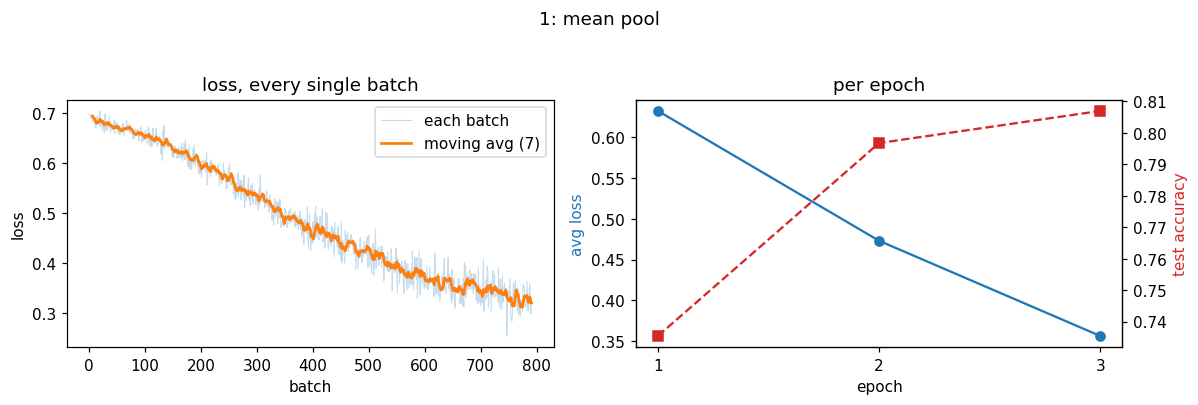

In [10]:
mean_model = MeanPoolClf()
report(mean_model)

hist_mean = train_model(mean_model, name="1: mean pool")

# Great — accuracy is nice.

But accuracy is a weak instrument here. Sentiment is *easy*: most of the signal is simply
**which** words are present, so every model we build today will land within a couple of points
of every other one, and the table will teach us nothing.

So put the number down for a second and reason about the *architecture* instead:

> Forget the data. Just reading the three lines of `forward` — what can we infer about how
> this model treats its input?

We embedded, and then we **summed** (a mean is a sum with a divide). Addition doesn't care
what order you add things in. So this model cannot notice word order — not "is bad at it",
*cannot*, and we know that before a single gradient has been computed.

Let's watch it. Two sentences, the same four words, opposite sentiment.

In [12]:
# Same words. Different order. Opposite meaning.
pos = "not bad but good"
neg = "not good but bad"

# Get the ID and mask using encode
# tok(..., padding="max_length", truncation=True,
#               max_length=MAXLEN, return_tensors="pt")
ids, mask = encode([pos, neg])                      # one batch of two

# PS: you can always convert IDs back to text
print(tok.convert_ids_to_tokens(ids[0][:6]))
print(tok.convert_ids_to_tokens(ids[1][:6]))

# Do the inference
with torch.no_grad():
    logits = mean_model(ids.to(device), mask.to(device))


# Is there a difference?
a, b = logits[0], logits[1]
print(f"\nlogit({pos!r}) = {a:.6f}")
print(f"logit({neg!r}) = {b:.6f}")
print(f"difference = {(a - b).mean():.2e}")

['[CLS]', 'not', 'bad', 'but', 'good', '[SEP]']
['[CLS]', 'not', 'good', 'but', 'bad', '[SEP]']

logit('not bad but good') = -2.540876
logit('not good but bad') = -2.540877
difference = 4.77e-07


### That difference is zero

![](../resources/imgs/6_2_wut)


In [13]:
# Those five lines again, wrapped up, so we can point it at every model we build today.
@torch.no_grad()
def order_probe(model, pos="not bad but good", neg="not good but bad"):
    ids, mask = encode([pos, neg])
    logits = model(ids.to(device), mask.to(device))
    d = (logits[0] - logits[1]).mean()
    print(f"{pos!r} -> {logits[0]:>9.6f} | {neg!r} -> {logits[1]:>9.6f} | diff {d:.2e}")
    return d

order_probe(mean_model)

'not bad but good' -> -2.540876 | 'not good but bad' -> -2.540877 | diff 4.77e-07


tensor(4.7684e-07, device='mps:0')

# Attempt 2: the obvious fix — more depth

We know from 5.0 what to do when a model isn't expressive enough: add a layer and a
non-linearity. So let's put a proper MLP after the pooling instead of a single `Linear`.

`embed -> masked mean -> Linear -> ReLU -> Linear -> one logit`

In [14]:
# LIVE: blank the head and the body of forward.
class MeanPoolMLPClf(nn.Module):

    def __init__(self, n_words=tok.vocab_size, n_dim=100, hidden=100, pad_id=tok.pad_token_id):
        super().__init__()
        self.embeddings = nn.Embedding(n_words, n_dim, padding_idx=pad_id)
        self.head = nn.Sequential(
            nn.Linear(n_dim, hidden),
            nn.ReLU(),
            nn.Linear(hidden, 1),
        )

    def forward(self, input_ids, attention_mask):
        H = self.embeddings(input_ids)                 # (B, T, D)
        context = masked_mean(H, attention_mask)       # (B, D)
        return self.head(context).squeeze(-1)          # (B,)

parameter                 shape                    count   learns?
------------------------------------------------------------------
embeddings.weight         (30522, 100)         3,052,200   yes
head.0.weight             (100, 100)              10,000   yes
head.0.bias               (100,)                     100   yes
head.2.weight             (1, 100)                   100   yes
head.2.bias               (1,)                         1   yes
------------------------------------------------------------------
                          TOTAL                3,062,401   (3,062,401 learn)


2: mean pool + MLP head:  33%|███▎      | 1/3 [00:03<00:06,  3.29s/it, loss=0.5804, test_acc=0.746]

epoch 0: avg loss = 0.5804  test acc = 0.746


2: mean pool + MLP head:  67%|██████▋   | 2/3 [00:06<00:03,  3.15s/it, loss=0.3690, test_acc=0.786]

epoch 1: avg loss = 0.3690  test acc = 0.786


2: mean pool + MLP head: 100%|██████████| 3/3 [00:09<00:00,  3.08s/it, loss=0.2790, test_acc=0.782]

epoch 2: avg loss = 0.2790  test acc = 0.782


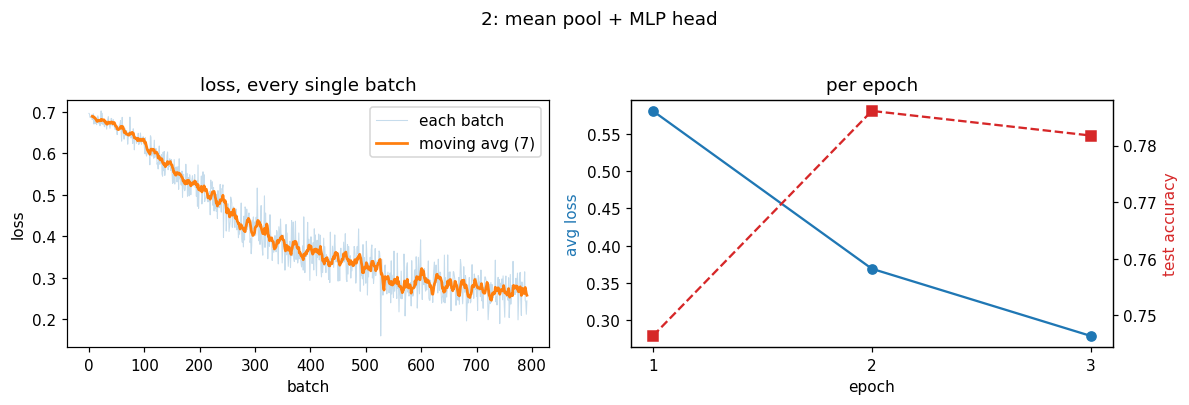

In [15]:
mlp_model = MeanPoolMLPClf()
report(mlp_model)

hist_mlp = train_model(mlp_model, name="2: mean pool + MLP head")

In [16]:
order_probe(mlp_model)

'not bad but good' -> -2.539208 | 'not good but bad' -> -2.539208 | diff 0.00e+00


tensor(0., device='mps:0')

# What do we see?

The model is slightly better to train. But no change in order permutation sensitivity

# Attempt 3: don't collapse it at all

If the mean is what's destroying things, let's just... not take the mean. Keep all `T x D`
numbers, flatten them into one long vector, and hand the whole thing to an MLP.

`embed -> flatten (T x D -> T*D) -> Linear -> ReLU -> Linear -> one logit`

If this feels familiar, it should. It's exactly what we did to images in 5.3.

In [17]:
# LIVE: blank the head and the body of forward. Make them work out the input dim (MAXLEN*n_dim).
class FlattenClf(nn.Module):

    def __init__(self, n_words=tok.vocab_size, n_dim=100, hidden=100,
                 maxlen=MAXLEN, pad_id=tok.pad_token_id):
        super().__init__()
        self.embeddings = nn.Embedding(n_words, n_dim, padding_idx=pad_id)
        self.head = nn.Sequential(
            nn.Linear(maxlen * n_dim, hidden),         # <- note what just happened to this number
            nn.ReLU(),
            nn.Linear(hidden, 1),
        )

    def forward(self, input_ids, attention_mask):
        H = self.embeddings(input_ids)                       # (B, T, D)
        H = H * attention_mask.unsqueeze(-1).float()         # zero out the padding
        return self.head(H.flatten(start_dim=1)).squeeze(-1) # (B, T*D) -> (B,)

In [26]:
flat_model = FlattenClf()
report(flat_model)          # look at `head.0.weight` before you run the next line

# For contrast: Attempt 1's entire classifier was 101 numbers.
print(f"PS: \n\tMaximum number of tokens: {MAXLEN}\n\tEmbedding of each token: {flat_model.head[0].out_features}")

parameter                 shape                    count   learns?
------------------------------------------------------------------
embeddings.weight         (30522, 100)         3,052,200   yes
head.0.weight             (100, 6400)            640,000   yes
head.0.bias               (100,)                     100   yes
head.2.weight             (1, 100)                   100   yes
head.2.bias               (1,)                         1   yes
------------------------------------------------------------------
                          TOTAL                3,692,401   (3,692,401 learn)
PS: 
	Maximum number of tokens: 64
	Embedding of each token: 100


3: flatten:  10%|█         | 1/10 [00:02<00:26,  2.96s/it, loss=0.1662, test_acc=0.728]

epoch 0: avg loss = 0.1662  test acc = 0.728


3: flatten:  20%|██        | 2/10 [00:05<00:23,  2.95s/it, loss=0.1151, test_acc=0.738]

epoch 1: avg loss = 0.1151  test acc = 0.738


3: flatten:  30%|███       | 3/10 [00:08<00:20,  2.97s/it, loss=0.0838, test_acc=0.751]

...

epoch 7: avg loss = 0.0273  test acc = 0.732


3: flatten:  90%|█████████ | 9/10 [00:26<00:02,  2.97s/it, loss=0.0190, test_acc=0.740]

epoch 8: avg loss = 0.0190  test acc = 0.740


3: flatten: 100%|██████████| 10/10 [00:29<00:00,  2.96s/it, loss=0.0162, test_acc=0.757]

epoch 9: avg loss = 0.0162  test acc = 0.757


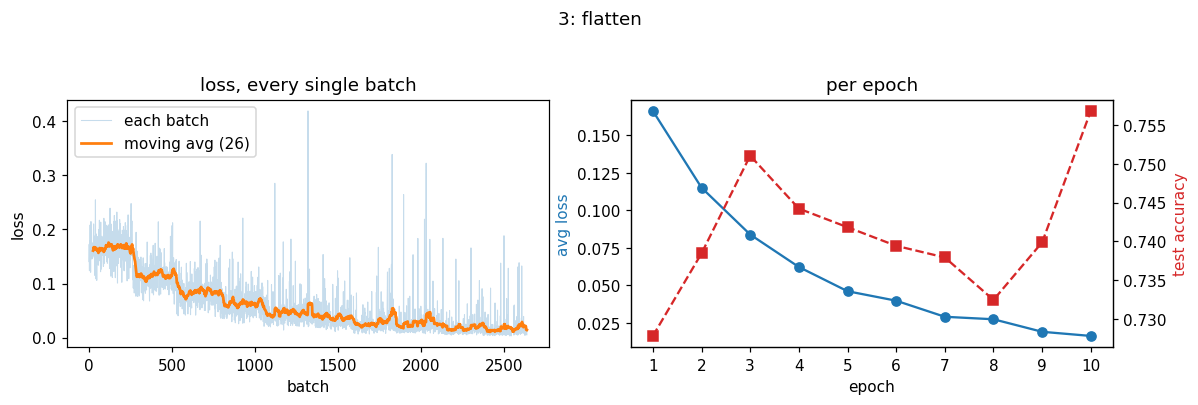

In [29]:
# oh well lets train it

hist_flat = train_model(flat_model, name="3: flatten", epochs=10)

In [31]:
order_probe(flat_model)

'not bad but good' -> -7.879788 | 'not good but bad' -> -6.226128 | diff -1.65e+00


tensor(-1.6537, device='mps:0')

In [32]:
# Same sentence, shifted right by two tokens. The words are identical.
shift_a = "the movie was not good"
shift_b = "well , the movie was not good"

for s in (shift_a, shift_b):
    ids, mask = encode([s])
    with torch.no_grad():
        print(f"{flat_model(ids.to(device), mask.to(device)).item():>9.4f}   {s}")

  -4.0029   the movie was not good
  11.6721   well , the movie was not good


**Okay great but the performance is worse? Why?**

# What is this model doing?

$$W @ [h_1; h_2; ...; h_T]  =  W_1 h_1 + W_2 h_2 + ... + W_T h_T$$

where $h_i$ is the token embedding of $i^{\text{th}}$ token. And $W_i$ is a **matrix** transforming token $i$. 

What the model learns about token position $i$ is almost independent of what it learns about token position $i+1$.

Ideal?

### Respecting the structure of data

In 5.3:
> "Each pixel contained some information but it also had information based on its
> neighbours. We took away this information."

Flattening an image destroyed the fact that a pixel's neighbours mean something. Flattening
a sentence destroys the fact that **a word means the same thing wherever it appears.**

In images, the fix was a kernel with *one* set of weights, slid over every position — so
whatever it learned about an edge, it knew everywhere. That property has a name:
**weight sharing.**

So here's what we actually want: process each token *separately* (don't collapse), but with
**the same weights at every position** (don't relearn 64 times).

What operation does that?

# Attempt 4: one `Linear`, applied to every token

Let's just try it and look at the shapes. Take some real embeddings and push them through a
`Linear` that has no idea sentences exist.

In [ ]:
ids, mask = encode(["the movie was not good"])
emb = nn.Embedding(tok.vocab_size, 100, padding_idx=tok.pad_token_id)

H = emb(ids)
print("H   :", H.shape)      # (B, T, D)

# How do I take this: batch (1) x time (64) x dim (100) embedding and apply a transformation such that
# the transformation is *same* for each token?

W = nn.Linear(100, 100)             # a layer that knows nothing about T
print("W(H):", W(H).shape)   # ...?

H   : torch.Size([1, 64, 100])
W(H): torch.Size([1, 64, 100])


#### Let's make a model out of this

In [44]:
# LIVE: blank `block`, `encode_tokens`, and the body of forward.
class TokenFFNClf(nn.Module):

    def __init__(self, n_words=tok.vocab_size, n_dim=100, hidden=100, pad_id=tok.pad_token_id):
        super().__init__()
        self.embeddings = nn.Embedding(n_words, n_dim, padding_idx=pad_id)
        
        self.block = nn.Sequential(               # an MLP, applied to each token separately
            nn.Linear(n_dim, hidden),
            nn.ReLU(),
            nn.Linear(hidden, n_dim),             # note: back to n_dim, so we can stack these
        )
        self.classifier = nn.Linear(n_dim, 1)

    def encode_tokens(self, input_ids):
        """(B, T) -> (B, T, D). Kept separate so we can look inside later."""
        return self.block(self.embeddings(input_ids))

    def forward(self, input_ids, attention_mask):
        H = self.encode_tokens(input_ids)              # (B, T, D)

        # Flatten time. Bye bye sequentiality
        context = masked_mean(H, attention_mask)       # (B, D)
        return self.classifier(context).squeeze(-1)    # (B,)

parameter                 shape                    count   learns?
------------------------------------------------------------------
embeddings.weight         (30522, 100)         3,052,200   yes
block.0.weight            (100, 100)              10,000   yes
block.0.bias              (100,)                     100   yes
block.2.weight            (100, 100)              10,000   yes
block.2.bias              (100,)                     100   yes
classifier.weight         (1, 100)                   100   yes
classifier.bias           (1,)                         1   yes
------------------------------------------------------------------
                          TOTAL                3,072,501   (3,072,501 learn)


4: position-wise FFN:  33%|███▎      | 1/3 [00:03<00:06,  3.02s/it, loss=0.5454, test_acc=0.774]

epoch 0: avg loss = 0.5454  test acc = 0.774


4: position-wise FFN:  67%|██████▋   | 2/3 [00:05<00:02,  2.99s/it, loss=0.3580, test_acc=0.794]

epoch 1: avg loss = 0.3580  test acc = 0.794


4: position-wise FFN: 100%|██████████| 3/3 [00:08<00:00,  3.00s/it, loss=0.2880, test_acc=0.794]

epoch 2: avg loss = 0.2880  test acc = 0.794


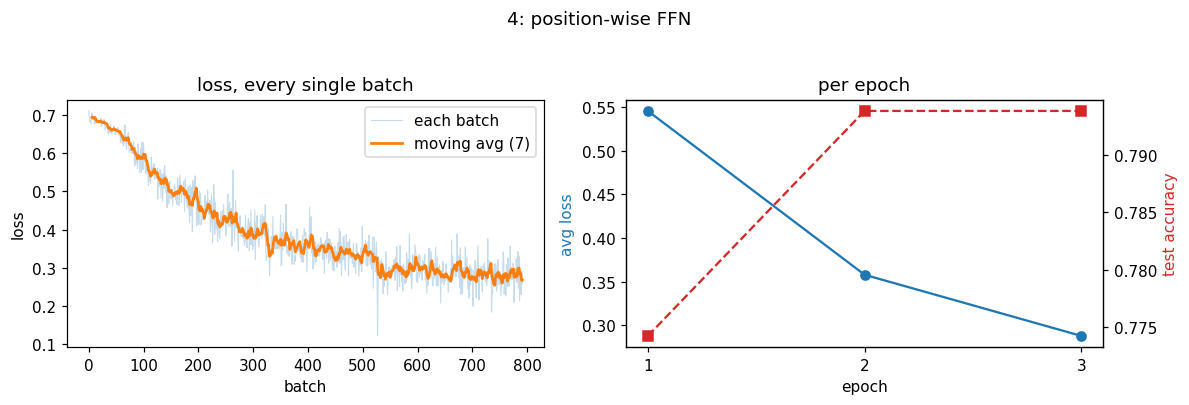

In [40]:
ffn_model = TokenFFNClf()
report(ffn_model)           # compare `block.0.weight` to Attempt 3's `head.0.weight`

hist_ffn = train_model(ffn_model, name="4: position-wise FFN")

# The audit

Accuracy is in the same neighbourhood as everything else. As promised, that tells us nothing.

So let's ask the two questions that matter, and be honest about the answers.

In [41]:
# Question 1: can it see word order now?
order_probe(ffn_model)

'not bad but good' -> -3.629937 | 'not good but bad' -> -3.629937 | diff 0.00e+00


tensor(0., device='mps:0')

### Zero again.

We're back to `1e-07`. All that new machinery and the model is, on this measure, exactly as
blind as Attempt 1 was.

Buuuuuuuut before the mean, we kinda sorta _were_ respecting the sequence. We flattened at the end of the model. Not at the start. 

In [42]:
# Question 2: what did the block actually do? Change ONE word and look at all T vectors.
a = "the movie was not good"
b = "the movie was not great"       # only the last word differs, and both are single tokens

ids_a, _ = encode([a]); ids_b, _ = encode([b])
with torch.no_grad():
    Ha = ffn_model.encode_tokens(ids_a.to(device))
    Hb = ffn_model.encode_tokens(ids_b.to(device))

n = 7                              # [CLS] the movie was not good [SEP]
delta = (Ha - Hb).abs().sum(dim=-1)[0, :n]

for t, d in zip(tok.convert_ids_to_tokens(ids_a[0][:n]), delta):
    print(f"  {d.item():>10.4f}   {t}")

      0.0000   [CLS]
      0.0000   the
      0.0000   movie
      0.0000   was
      0.0000   not
     55.9368   good
      0.0000   [SEP]


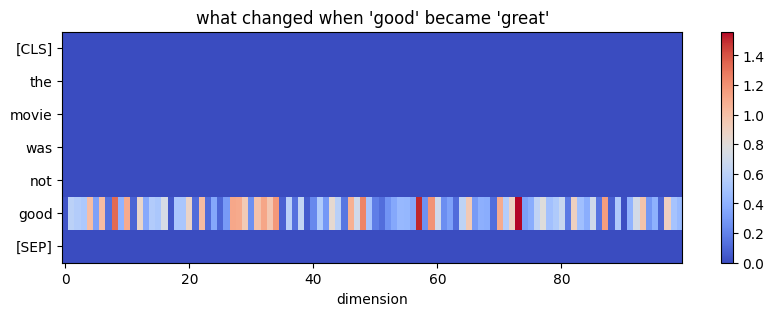

In [43]:
# Same thing as a picture: rows = positions, columns = the 100 dims. How much did each move?
plt.figure(figsize=(10, 3))
plt.imshow((Ha - Hb).abs()[0, :n].cpu(), aspect='auto', cmap='coolwarm')
plt.yticks(range(n), tok.convert_ids_to_tokens(ids_a[0][:n]))
plt.xlabel("dimension"); plt.title("what changed when 'good' became 'great'")
plt.colorbar()

### Sidenote

When we encode token 2: the, the model has no idea of what 
- other tokens are
- where this token sits in the sequence.

Ideal?

# An aside: where do the embeddings come from?

Before we change the architecture, let's rule out the other suspect.

Every model so far started from `nn.Embedding(30522, 100)` filled with **random numbers**.
In 6.1 we spent a whole session on the fact that good word vectors are hard-won — so maybe
the problem isn't the architecture at all. Maybe our vectors are just bad.

Handily, we're already using BERT's tokenizer. Which means BERT's *embedding table* is indexed
by exactly the same ids we're feeding in. We can just... take it.

In [48]:
from transformers import AutoModel

bert = AutoModel.from_pretrained("bert-base-uncased")

# Inside BERT is an nn.Embedding, exactly like ours — just bigger, and trained on a lot of text.
bert_emb = bert.embeddings.word_embeddings
type(bert_emb), bert_emb.weight.shape          # (30522, 768)

(torch.nn.modules.sparse.Embedding, torch.Size([30522, 768]))

In [49]:
# Sanity check that it is a lookup table and nothing more: same ids in, one vector per token out.
ids, mask = encode(["the movie was not good"])
bert_emb(ids[:, :7]).shape

torch.Size([1, 7, 768])

### It's the same object we've been building

`nn.Embedding(30522, 768)`. A matrix with one row per token, and `forward` is a row lookup.
That's it. The thing we wrote in 6.1.2 with `n_dim=100` and trained for five minutes on
wikitext, except this one is 768-wide and was trained on 3.3 billion words.

So let's swap it in. Two details:

- **`freeze=True`.** We are borrowing someone else's vectors, not fine-tuning them —
  and 23 million embedding parameters would dominate training otherwise.
- **`n_dim` becomes 768**, so everything downstream widens to match. Nothing else changes.

In [54]:
class BertEmbTokenFFNClf(nn.Module):

    def __init__(self, n_words=tok.vocab_size, n_dim=768, hidden=100, pad_id=tok.pad_token_id):
        super().__init__()
        self.embeddings = nn.Embedding.from_pretrained(
                    bert.embeddings.word_embeddings.weight.clone(),
                    freeze=True, padding_idx=tok.pad_token_id)        
        self.block = nn.Sequential(               # an MLP, applied to each token separately
            nn.Linear(n_dim, hidden),
            nn.ReLU(),
            nn.Linear(hidden, n_dim),             # note: back to n_dim, so we can stack these
        )
        self.classifier = nn.Linear(n_dim, 1)

    def encode_tokens(self, input_ids):
        """(B, T) -> (B, T, D). Kept separate so we can look inside later."""
        return self.block(self.embeddings(input_ids))

    def forward(self, input_ids, attention_mask):
        H = self.encode_tokens(input_ids)              # (B, T, D)

        # Flatten time. Bye bye sequentiality
        context = masked_mean(H, attention_mask)       # (B, D)
        return self.classifier(context).squeeze(-1)    # (B,)

parameter                 shape                    count   learns?
------------------------------------------------------------------
embeddings.weight         (30522, 768)        23,440,896   FROZEN
block.0.weight            (100, 768)              76,800   yes
block.0.bias              (100,)                     100   yes
block.2.weight            (768, 100)              76,800   yes
block.2.bias              (768,)                     768   yes
classifier.weight         (1, 768)                   768   yes
classifier.bias           (1,)                         1   yes
------------------------------------------------------------------
                          TOTAL               23,596,133   (155,237 learn)


aside: BERT embeddings + mean pool:  33%|███▎      | 1/3 [00:04<00:09,  4.84s/it, loss=0.4550, test_acc=0.727]

epoch 0: avg loss = 0.4550  test acc = 0.727


aside: BERT embeddings + mean pool:  67%|██████▋   | 2/3 [00:08<00:04,  4.23s/it, loss=0.3695, test_acc=0.772]

epoch 1: avg loss = 0.3695  test acc = 0.772


aside: BERT embeddings + mean pool: 100%|██████████| 3/3 [00:12<00:00,  4.23s/it, loss=0.3604, test_acc=0.788]

epoch 2: avg loss = 0.3604  test acc = 0.788


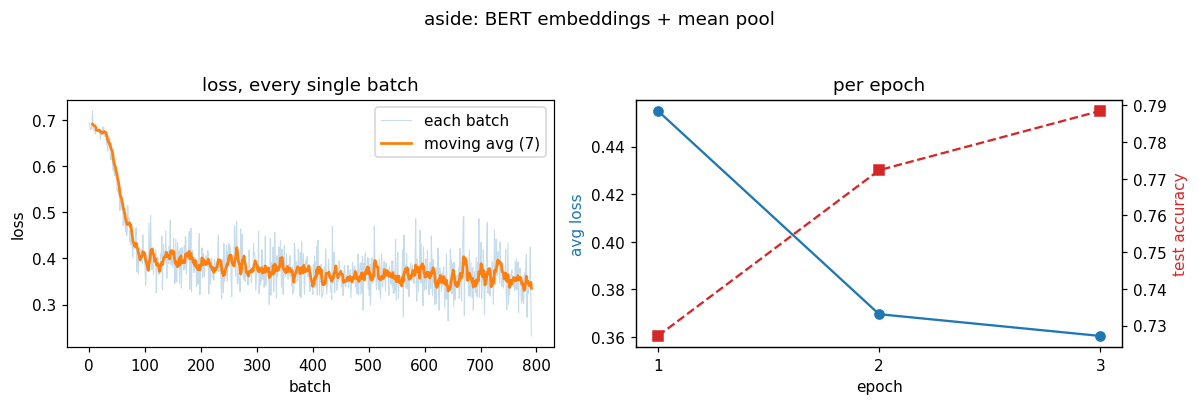

In [55]:
bert_mean_model = BertEmbTokenFFNClf()
report(bert_mean_model)     # note the FROZEN row, and how much of the model it is

hist_bert = train_model(bert_mean_model, name="aside: BERT embeddings + mean pool")

In [56]:
order_probe(bert_mean_model)

'not bad but good' -> -3.126635 | 'not good but bad' -> -3.126635 | diff 0.00e+00


tensor(0., device='mps:0')

### Better vectors. Same zero.

The accuracy probably ticked up a little — real vectors are better than random ones, and that's
a genuine (free) win worth taking.

But the probe hasn't budged. **Google's embeddings can't save a mean.** Whatever we averaged,
we averaged, and the order was gone before the head ever saw it. That's the point of running
this aside here: it rules out the representation as the culprit and leaves only the architecture.

### One honest warning, because this is a common confusion

We did **not** just "use BERT". We took its lookup table and threw away the other 99% of it.

The embedding table is *context-independent* — `bank` gets one vector whether the sentence is
about rivers or money, exactly like our word2vec vectors in 6.1.1. Everything that makes BERT
*BERT* lives in the twelve layers we didn't touch, and those layers are made of the thing we
still haven't built.

Which is a good moment to get back to building it.

# Stuff to try (optional, obviously)

- Stack two blocks instead of one (`nn.Sequential(block, block2)`). Does the probe change?
  (Predict first. Then check.)
- Swap `masked_mean` for "just take the `[CLS]` vector" — `H[:, 0]`. What happens to the
  order probe, and why? (This one's a good trap.)
- Delete the `attention_mask` from `masked_mean` and average over everything including
  padding. How much accuracy does the lie cost you?
- Give `TokenFFNClf` the frozen BERT embeddings too (`n_dim=768`). Does starting from real
  vectors change what the position-wise block manages to learn?
- Unfreeze the BERT embeddings (`freeze=False`) and watch what happens to training time and
  to accuracy. Was freezing the right call?
- Try the Word2Vec vectors from 6.1.1 in place of BERT's. Harder than it sounds — those are
  *word* vectors and our tokenizer emits *subwords*, so you have to decide what the vector for
  `##ization` should be. Worth attempting just to feel why subword changed everything.
- Run the flatten model on a sentence longer than `MAXLEN` and watch it refuse.

# Further Reading

- *Attention Is All You Need* — https://arxiv.org/abs/1706.03762. The FFN we just built is
  section 3.3, and it's four lines long. Everything else in that paper is next session.
- The Illustrated Transformer — https://jalammar.ar/illustrated-transformer/ — for the
  pictures. (Read it *after* 6.3, not before.)
- Subword tokenization, if you want the rabbit hole: HuggingFace's tokenizer summary —
  https://huggingface.co/docs/transformers/tokenizer_summary